In [1]:
#Anabela Petrushevikj
#D213 Task 2

In [2]:
#Libraries
import os
import re
import json
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
#File path
AMAZON_PATH = "amazon_cells_labelled_D213.txt"
IMDB_PATH   = "imdb_labelled_D213.txt"
YELP_PATH   = "yelp_labelled_D213.txt"

In [5]:
#Output folder
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
#Load and merge datasets
def load_ucisls_file(path: str, source_name: str) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Most lines are: sentence \t label
            parts = line.split("\t")
            if len(parts) < 2:
                # If a malformed line exists, skip it safely
                continue

            text = "\t".join(parts[:-1]).strip()
            label = parts[-1].strip()

            # Ensure label is 0/1
            if label not in {"0", "1"}:
                continue

            rows.append((text, int(label), source_name))

    return pd.DataFrame(rows, columns=["text", "label", "source"])


df_amazon = load_ucisls_file(AMAZON_PATH, "amazon")
df_imdb   = load_ucisls_file(IMDB_PATH, "imdb")
df_yelp   = load_ucisls_file(YELP_PATH, "yelp")

df = pd.concat([df_amazon, df_imdb, df_yelp], ignore_index=True)

print("Merged dataset shape:", df.shape)
display(df.head())

Merged dataset shape: (3000, 3)


,text,label,source
0,So there is no way for me to plug it in here i...,0,amazon
1,"Good case, Excellent value.",1,amazon
2,Great for the jawbone.,1,amazon
3,Tied to charger for conversations lasting more...,0,amazon
4,The mic is great.,1,amazon


In [7]:
#Quick label distribution
print("Label distribution (counts):")
display(df["label"].value_counts().sort_index())

print("\nLabel distribution (percentages):")
display((df["label"].value_counts(normalize=True) * 100).round(2).sort_index())

print("\nSource distribution (counts):")
display(df["source"].value_counts())

print("\nSource distribution (percentages):")
display((df["source"].value_counts(normalize=True) * 100).round(2))

Label distribution (counts):


label
0    1500
1    1500
Name: count, dtype: int64


Label distribution (percentages):


label
0    50.0
1    50.0
Name: proportion, dtype: float64


Source distribution (counts):


source
amazon    1000
imdb      1000
yelp      1000
Name: count, dtype: int64


Source distribution (percentages):


source
amazon    33.33
imdb      33.33
yelp      33.33
Name: proportion, dtype: float64

In [8]:
#Data Cleaning / Normalization
def detect_unusual_characters(text: str) -> bool:
    #Returns True if text contains characters outside basic ASCII range.
    #Used to identify emojis or non-English symbols for EDA.
    return any(ord(ch) > 127 for ch in text)

#Identify unusual (non-ASCII) rows
df["has_unusual_chars"] = df["text"].apply(detect_unusual_characters)
unusual_count = df["has_unusual_chars"].sum()

print(f"Rows with unusual (non-ASCII) characters: {unusual_count} / {len(df)}")

if unusual_count > 0:
    print("\nExamples with unusual characters:")
    display(df.loc[df["has_unusual_chars"], "text"].head(5))


def clean_text(text: str) -> str:
    text = text.strip()

    #Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    #Lowercase
    text = text.lower()

    #Replace non-breaking spaces
    text = text.replace("\u00a0", " ")

    #Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    #Remove digits
    text = re.sub(r"\d+", "", text)

    #Remove non-ASCII characters
    text = text.encode("ascii", errors="ignore").decode()

    #Collapse extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["text_clean"] = df["text"].apply(clean_text)

Rows with unusual (non-ASCII) characters: 17 / 3000

Examples with unusual characters:


1018    It's practically perfect in all of them  a tr...
1080    I'm glad this pretentious piece of s*** didn't...
1178                    The script is
was there a script?
1182            I'll even say it again  this is torture.
1424    This show is made for Americans - it is too st...
Name: text, dtype: object

In [9]:
#Remove any empty rows
before = len(df)

df = df[df["text_clean"].str.len() > 0].copy()

after = len(df)

print(f"Removed {before - after} empty rows after cleaning.")
print(f"New dataset shape: {df.shape}")

Removed 2 empty rows after cleaning.
New dataset shape: (2998, 5)


In [10]:
#Remove duplicates
before = len(df)

df = df.drop_duplicates(subset=["text_clean", "label"]).copy()

after = len(df)

print(f"Removed {before - after} duplicate rows.")
print(f"New dataset shape: {df.shape}")

Removed 30 duplicate rows.
New dataset shape: (2968, 5)


In [11]:
#Save cleaned merged dataset
cleaned_path = os.path.join(OUTPUT_DIR, "merged_cleaned_dataset.csv")

df[["text_clean", "label", "source"]].to_csv(cleaned_path, index=False)

print(f"Saved cleaned dataset to: {cleaned_path}")

Saved cleaned dataset to: output\merged_cleaned_dataset.csv


In [12]:
#EDA: Vocabulary Size, Sequence Lengths, Embedding Length Proposal
tokens = []
lengths = []

for text in df["text_clean"]:
    words = text.split()
    tokens.extend(words)
    lengths.append(len(words))

#Vocabulary size (EDA estimate)
vocab_size_basic = len(set(tokens))
print(f"Estimated vocabulary size (whitespace tokenization): {vocab_size_basic}")

#Sentence length statistics
lengths = np.array(lengths)

stats = {
    "min": int(lengths.min()),
    "25%": float(np.percentile(lengths, 25)),
    "median": float(np.percentile(lengths, 50)),
    "75%": float(np.percentile(lengths, 75)),
    "90%": float(np.percentile(lengths, 90)),
    "95%": float(np.percentile(lengths, 95)),
    "max": int(lengths.max())
}

print("\nSentence length stats (in words):")
for k, v in stats.items():
    print(f"{k}: {v}")

vocab_size_basic, stats

Estimated vocabulary size (whitespace tokenization): 5301

Sentence length stats (in words):
min: 1
25%: 6.0
median: 10.0
75%: 16.0
90%: 22.0
95%: 25.0
max: 70


(5301,
 {'min': 1,
  '25%': 6.0,
  'median': 10.0,
  '75%': 16.0,
  '90%': 22.0,
  '95%': 25.0,
  'max': 70})

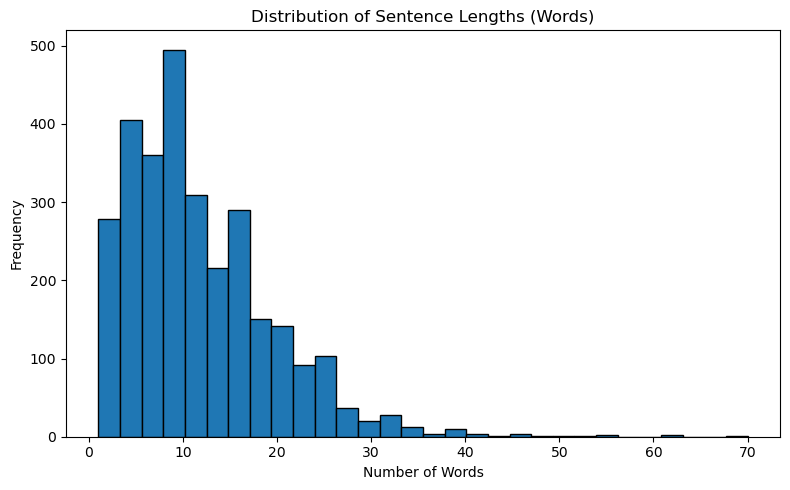

In [13]:
#Plot sentence length distribution
plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=30, edgecolor="black")
plt.title("Distribution of Sentence Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [14]:
#Maximum Sequence Length 95th percentile
max_seq_len = int(np.percentile(lengths, 95))

max_seq_len = max(max_seq_len, 5)

print(f"Chosen MAX_SEQUENCE_LENGTH (95th percentile): {max_seq_len}")
print("This covers approximately 95% of all sentences in the dataset.")

Chosen MAX_SEQUENCE_LENGTH (95th percentile): 25
This covers approximately 95% of all sentences in the dataset.


In [15]:
#Embedding length:
EMBEDDING_DIM = 64 

print(f"Selected EMBEDDING_DIM: {EMBEDDING_DIM}")

Selected EMBEDDING_DIM: 64


In [16]:
#Tokenization
MAX_VOCAB_SIZE = 6000  

#Token used for words not seen during training
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

#Fitting tokenizer on cleaned training text
tokenizer.fit_on_texts(df["text_clean"].tolist())

In [17]:
#Actual vocab used by tokenizer
word_index = tokenizer.word_index

actual_vocab_size = min(MAX_VOCAB_SIZE, len(word_index) + 1)

print(f"Total unique tokens found: {len(word_index)}")
print(f"Actual vocabulary size used in model: {actual_vocab_size}")

Total unique tokens found: 5302
Actual vocabulary size used in model: 5303


In [18]:
#Convert to sequences
sequences = tokenizer.texts_to_sequences(df["text_clean"].tolist())

print(f"Number of sequences created: {len(sequences)}")
print("Example sequence (before padding):")
print(sequences[0])

Number of sequences created: 2968
Example sequence (before padding):
[28, 48, 6, 57, 117, 13, 72, 7, 364, 8, 12, 66, 12, 2, 179, 632, 4, 76, 61, 5, 2185]


In [19]:
#Padding
PADDING_TYPE = "post"   
TRUNC_TYPE   = "post"  

X = pad_sequences(
    sequences,
    maxlen=max_seq_len,
    padding=PADDING_TYPE,
    truncating=TRUNC_TYPE
)

#Target variable
y = df["label"].values.astype(np.int32)

print(f"Padded feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

Padded feature matrix shape: (2968, 25)
Label vector shape: (2968,)


In [20]:
#Single padded sequence:
sample_index = 0

print("Example padded sequence (index 0):")
print(X[sample_index])

Example padded sequence (index 0):
[  28   48    6   57  117   13   72    7  364    8   12   66   12    2
  179  632    4   76   61    5 2185    0    0    0    0]


In [21]:
#Train / Validation / Test Split (70/15/15)
#First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

#Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Dataset split sizes:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Dataset split sizes:
Train: (2077, 25)
Validation: (445, 25)
Test: (446, 25)


In [22]:
#Save prepared dataset 
prepared_dataset_path = os.path.join(OUTPUT_DIR, "prepared_dataset.csv")

df[["text_clean", "label", "source"]].to_csv(prepared_dataset_path, index=False)
print(f"\nSaved prepared dataset to: {prepared_dataset_path}")


Saved prepared dataset to: output\prepared_dataset.csv


In [23]:
#Identify Sentiment Categories
NUM_CLASSES = 2  # Binary classification: Negative (0), Positive (1)
FINAL_ACTIVATION = "sigmoid"  # Appropriate for binary classification

print(f"Number of sentiment categories: {NUM_CLASSES}")
print(f"Final layer activation function: {FINAL_ACTIVATION}")

Number of sentiment categories: 2
Final layer activation function: sigmoid


In [24]:
#Model Hyperparameters
EMBEDDING_DIM = 64   
RNN_UNITS = 32       
DROPOUT = 0.5      

print("Model Hyperparameters:")
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"LSTM units: {RNN_UNITS}")
print(f"Dropout rate: {DROPOUT}")


#Build Neural Network
model = models.Sequential([
    layers.Input(shape=(max_seq_len,)),

    #Embedding layer learns dense vector representations of words
    layers.Embedding(
        input_dim=actual_vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    #Bidirectional LSTM captures context from both directions
    layers.Bidirectional(
        layers.LSTM(RNN_UNITS, return_sequences=False)
    ),

    #Dropout helps reduce overfitting
    layers.Dropout(DROPOUT),

    #Dense layer for nonlinear transformation
    layers.Dense(16, activation="relu"),

    #Output layer: sigmoid for binary classification
    layers.Dense(1, activation="sigmoid")
])


#Compile Model
model.compile(
    loss="binary_crossentropy",            
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

Model Hyperparameters:
Embedding dimension: 64
LSTM units: 32
Dropout rate: 0.5


In [25]:
#Model summary
print("\nModel Summary:")
model.summary()


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 64)         │       339,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,281 (1.39 MB)

 Trainable params: 365,281 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#Train with Stopping Criteria
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

#Display final epoch reached
final_epoch = len(history.history["loss"])
print(f"\nTraining stopped after {final_epoch} epochs due to early stopping.")

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.5118 - loss: 0.6928 - val_accuracy: 0.5685 - val_loss: 0.6861
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7227 - loss: 0.5970 - val_accuracy: 0.7416 - val_loss: 0.5126
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8984 - loss: 0.2751 - val_accuracy: 0.8045 - val_loss: 0.4663
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9634 - loss: 0.1208 - val_accuracy: 0.8090 - val_loss: 0.6728
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9745 - loss: 0.0807 - val_accuracy: 0.7933 - val_loss: 0.6439
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9904 - loss: 0.0425 - val_accuracy: 0.7865 - val_loss: 0.8282

Training stopped after 6 epochs due to early stopping.


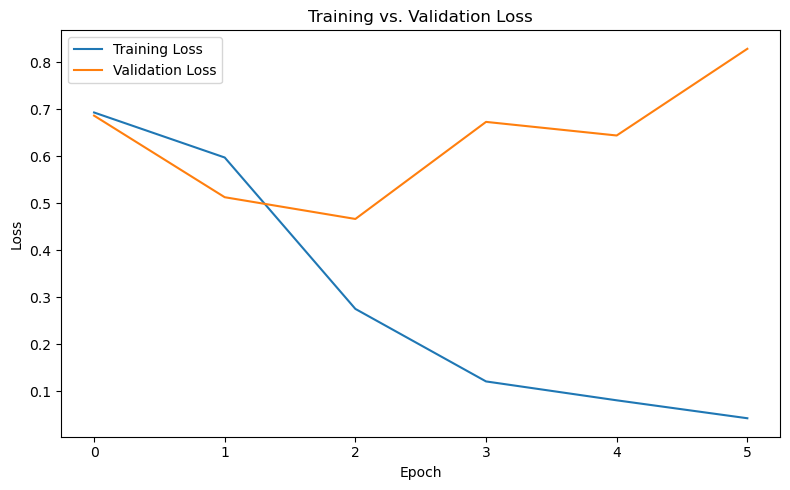

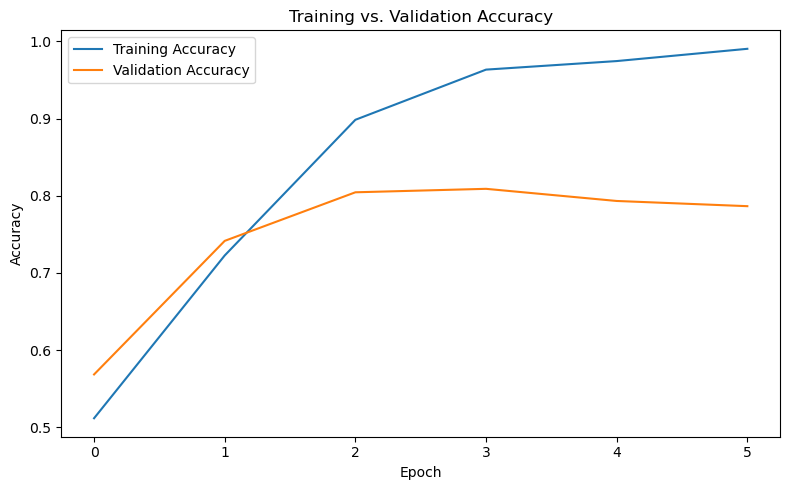

In [27]:
#Visualizations: Loss and Accuracy
loss = history.history["loss"]
val_loss = history.history["val_loss"]
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

#Plot: Loss
plt.figure(figsize=(8, 5))
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("Training vs. Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

#Plot: Accuracy
plt.figure(figsize=(8, 5))
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
#Evaluate Model on Test Set
#Evaluate overall performance
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test Set Performance:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")

#Generate predictions
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

#Classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\nDetailed Classification Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Test Set Performance:
Loss: 0.4382
Accuracy: 0.8341
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step

Detailed Classification Metrics:
Accuracy : 0.8341
Precision: 0.8433
Recall   : 0.8206
F1 Score : 0.8318


<Figure size 600x600 with 0 Axes>

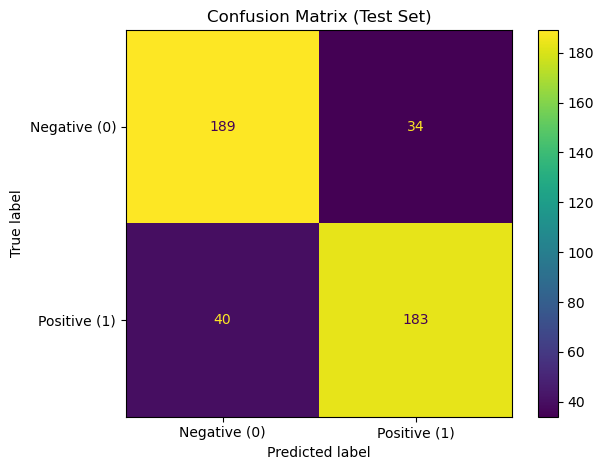

In [29]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative (0)", "Positive (1)"]
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="viridis", values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [30]:
#Saving the Trained Model
model_save_path = os.path.join(OUTPUT_DIR, "sentiment_bilstm_model.keras")

model.save(model_save_path)

print(f"Model location: {model_save_path}")

Model location: output\sentiment_bilstm_model.keras
